In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import ipywidgets as widgets
from IPython.display import display, clear_output

Upload a JPG or PNG image:


Saving cat02.jpg to cat02.jpg
Image uploaded: cat02.jpg


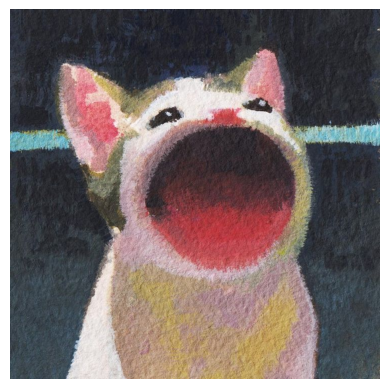

In [2]:
print("Upload a JPG or PNG image:")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

img = Image.open(filename).convert("RGB")
img = np.array(img)

original_img = img.copy()

print("Image uploaded:", filename)

plt.imshow(img)
plt.axis("off")
plt.show()

In [3]:
def transform_image(img, A):

    height, width = img.shape[:2]

    # Centre of image
    cx = width // 2
    cy = height // 2

    # Create empty output image
    new_img = np.zeros_like(img)

    # Go through every pixel
    for y in range(height):
        for x in range(width):

            # Coordinates with origin at centre
            X = x - cx
            Y = y - cy

            # Apply matrix
            new_X = A[0, 0] * X + A[0, 1] * Y
            new_Y = A[1, 0] * X + A[1, 1] * Y

            # Convert back to image coordinates
            new_x = int(new_X + cx)
            new_y = int(new_Y + cy)

            # Check whether pixel is inside image
            if 0 <= new_x < width and 0 <= new_y < height:

                new_img[new_y, new_x] = img[y, x]

    return new_img

In [4]:
menu = widgets.Dropdown(
    options=[
        "Rotate",
        "Resize",
        "Flip",
        "Shear",
        "Custom Matrix",
        "Reset"
    ],
    description="Operation:"
)

display(menu)

Dropdown(description='Operation:', options=('Rotate', 'Resize', 'Flip', 'Shear', 'Custom Matrix', 'Reset'), va…

In [5]:
angle = widgets.FloatText(
    value=90,
    description="Angle:"
)

scale = widgets.FloatText(
    value=1.5,
    description="Scale:"
)

flip_direction = widgets.Dropdown(
    options=["Horizontal", "Vertical"],
    description="Flip:"
)

shear_factor = widgets.FloatText(
    value=0.5,
    description="Shear:"
)

a = widgets.FloatText(value=1, description="a:")
b = widgets.FloatText(value=0, description="b:")
c = widgets.FloatText(value=0, description="c:")
d = widgets.FloatText(value=1, description="d:")

apply_button = widgets.Button(
    description="Apply Transformation"
)

output = widgets.Output()

In [6]:
def apply_transformation(button):

    global img

    with output:
        clear_output()

        operation = menu.value

        # ---------------- ROTATE ----------------
        if operation == "Rotate":

            theta = np.radians(angle.value)

            A = np.array([
                [np.cos(theta), -np.sin(theta)],
                [np.sin(theta),  np.cos(theta)]
            ])

            img = transform_image(img, A)

        # ---------------- RESIZE ----------------
        elif operation == "Resize":

            s = scale.value

            A = np.array([
                [s, 0],
                [0, s]
            ])

            img = transform_image(img, A)

        # ---------------- FLIP ----------------
        elif operation == "Flip":

            if flip_direction.value == "Horizontal":

                A = np.array([
                    [-1, 0],
                    [0, 1]
                ])

            else:

                A = np.array([
                    [1, 0],
                    [0, -1]
                ])

            img = transform_image(img, A)

        # ---------------- SHEAR ----------------
        elif operation == "Shear":

            k = shear_factor.value

            A = np.array([
                [1, k],
                [0, 1]
            ])

            img = transform_image(img, A)

        # ---------------- CUSTOM MATRIX ----------------
        elif operation == "Custom Matrix":

            A = np.array([
                [a.value, b.value],
                [c.value, d.value]
            ])

            img = transform_image(img, A)

        # ---------------- RESET ----------------
        elif operation == "Reset":

            img = original_img.copy()

        # Display result
        plt.figure(figsize=(7, 7))
        plt.imshow(img)
        plt.axis("off")
        plt.title(operation)
        plt.show()


apply_button.on_click(apply_transformation)

In [7]:
display(menu)

display(angle)
display(scale)
display(flip_direction)
display(shear_factor)

print("Custom Matrix:")
display(a, b, c, d)

display(apply_button)
display(output)

Dropdown(description='Operation:', options=('Rotate', 'Resize', 'Flip', 'Shear', 'Custom Matrix', 'Reset'), va…

FloatText(value=90.0, description='Angle:')

FloatText(value=1.5, description='Scale:')

Dropdown(description='Flip:', options=('Horizontal', 'Vertical'), value='Horizontal')

FloatText(value=0.5, description='Shear:')

...

FloatText(value=0.0, description='b:')

FloatText(value=0.0, description='c:')

FloatText(value=1.0, description='d:')

Button(description='Apply Transformation', style=ButtonStyle())

Output()